In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.linear_model import Perceptron    # Used for simple linear classification tasks.

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential     # Sequential lets you build a neural network layer-by-layer in Keras.

from tensorflow.keras.layers import Dense     #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D     # Conv2D extracts features
from tensorflow.keras.layers import Flatten    # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D     # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical

In [3]:
df = pd.read_csv("train.csv")
df_test = pd.read_csv("test.csv")

In [4]:
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df_test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(42000, 785)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


In [8]:
df.columns

Index(['label', 'pixel0', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5',
       'pixel6', 'pixel7', 'pixel8',
       ...
       'pixel774', 'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779',
       'pixel780', 'pixel781', 'pixel782', 'pixel783'],
      dtype='str', length=785)

In [9]:
df.isnull().sum()

label       0
pixel0      0
pixel1      0
pixel2      0
pixel3      0
           ..
pixel779    0
pixel780    0
pixel781    0
pixel782    0
pixel783    0
Length: 785, dtype: int64

In [12]:
X= df.drop("label", axis=1).values
y= df["label"].values


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [14]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [30]:
Xtrain_img=X_train.reshape(-1,28,28)
Xtest_img=X_test.reshape(-1,28,28)

In [31]:
y_train_cat=to_categorical(y_train,10)
y_test_cat=to_categorical(y_test,10)

In [32]:
Perceptron=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation = "softmax")
])

In [33]:
Perceptron.compile(optimizer='sgd',loss="categorical_crossentropy",metrics=["accuracy"])

In [35]:
history_percep=Perceptron.fit(Xtrain_img,y_train_cat,epochs=10,batch_size=32, validation_data=(Xtest_img,y_test_cat),verbose=1)

Epoch 1/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8949 - loss: 0.3924 - val_accuracy: 0.8907 - val_loss: 0.3922
Epoch 2/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8983 - loss: 0.3787 - val_accuracy: 0.8937 - val_loss: 0.3807
Epoch 3/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9001 - loss: 0.3679 - val_accuracy: 0.8957 - val_loss: 0.3717
Epoch 4/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9030 - loss: 0.3591 - val_accuracy: 0.8970 - val_loss: 0.3645
Epoch 5/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9038 - loss: 0.3517 - val_accuracy: 0.9001 - val_loss: 0.3578
Epoch 6/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9053 - loss: 0.3453 - val_accuracy: 0.9017 - val_loss: 0.3533
Epoch 7/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9059 - loss: 0.3398 - val_accuracy: 0.9028 - val_loss: 0.3487
Epoch 8/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9079 - loss: 0.3351 - val_accuracy: 0.

In [40]:
acc_percep=Perceptron.evaluate(Xtest_img,y_test_cat,verbose=0)

In [41]:
acc_percep

[0.33790844678878784, 0.90505051612854]

In [48]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [49]:
ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=['accuracy'])

In [50]:
history_ann=ann.fit(Xtrain_img,y_train_cat,epochs=10,batch_size=32,validation_data=(Xtest_img,y_test_cat),verbose=1)

Epoch 1/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9031 - loss: 0.3360 - val_accuracy: 0.9430 - val_loss: 0.1916
Epoch 2/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9576 - loss: 0.1408 - val_accuracy: 0.9595 - val_loss: 0.1347
Epoch 3/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9715 - loss: 0.0944 - val_accuracy: 0.9665 - val_loss: 0.1146
Epoch 4/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9790 - loss: 0.0684 - val_accuracy: 0.9649 - val_loss: 0.1108
Epoch 5/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9832 - loss: 0.0531 - val_accuracy: 0.9642 - val_loss: 0.1174
Epoch 6/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9869 - loss: 0.0416 - val_accuracy: 0.9685 - val_loss: 0.1121
Epoch 7/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9896 - loss: 0.0334 - val_accuracy: 0.9675 - val_loss: 0.1150
Epoch 8/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9908 - loss: 0.0281 - val_accuracy: 0.

In [51]:
acc_ann=ann.evaluate(Xtest_img,y_test_cat)

434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9702 - loss: 0.1244


In [52]:
acc_ann

[0.12441609054803848, 0.9702020287513733]

In [56]:
Xtrain_cnn=X_train.reshape(-1,28,28,1)
Xtest_cnn=X_test.reshape(-1,28,28,1)

In [60]:
cnn=Sequential([
    Conv2D(32,kernel_size=(3,3),activation="relu",input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation="relu"),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(128,activation="relu"),
    Dropout(0.5),
    Dense(10,activation="softmax")
])

In [61]:
cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])


In [62]:
history_cnn=cnn.fit(Xtrain_cnn,y_train_cat,epochs=10,batch_size=32,validation_data=(Xtest_cnn,y_test_cat),verbose=1)

Epoch 1/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9014 - loss: 0.3208 - val_accuracy: 0.9716 - val_loss: 0.0903
Epoch 2/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9668 - loss: 0.1103 - val_accuracy: 0.9817 - val_loss: 0.0581
Epoch 3/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9743 - loss: 0.0840 - val_accuracy: 0.9838 - val_loss: 0.0493
Epoch 4/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9789 - loss: 0.0705 - val_accuracy: 0.9876 - val_loss: 0.0421
Epoch 5/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9829 - loss: 0.0584 - val_accuracy: 0.9872 - val_loss: 0.0425
Epoch 6/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9859 - loss: 0.0470 - val_accuracy: 0.9885 - val_loss: 0.0387
Epoch 7/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - accuracy: 0.9861 - loss: 0.0448 - val_accuracy: 0.9887 - val_loss: 0.0377
Epoch 8/10
880/880 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9884 - loss: 0.0383 - v

In [63]:
cnn_pred=cnn.evaluate(Xtest_cnn,y_test_cat)

434/434 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9908 - loss: 0.0324


In [64]:
cnn_pred

[0.032429084181785583, 0.9908369183540344]

In [65]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()
     

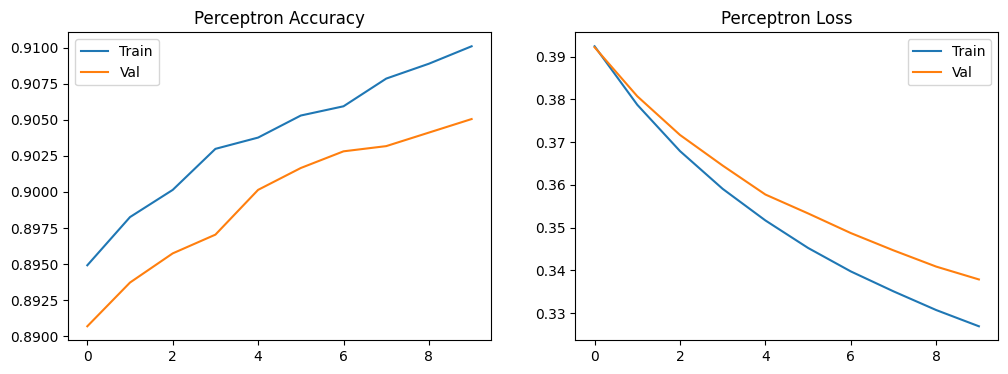

In [68]:

plot_training(history_percep, "Perceptron")

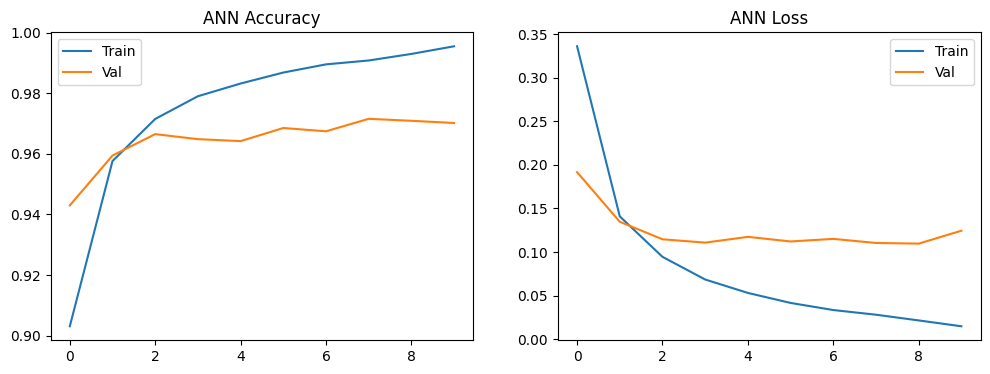

In [69]:

plot_training(history_ann, "ANN")
  

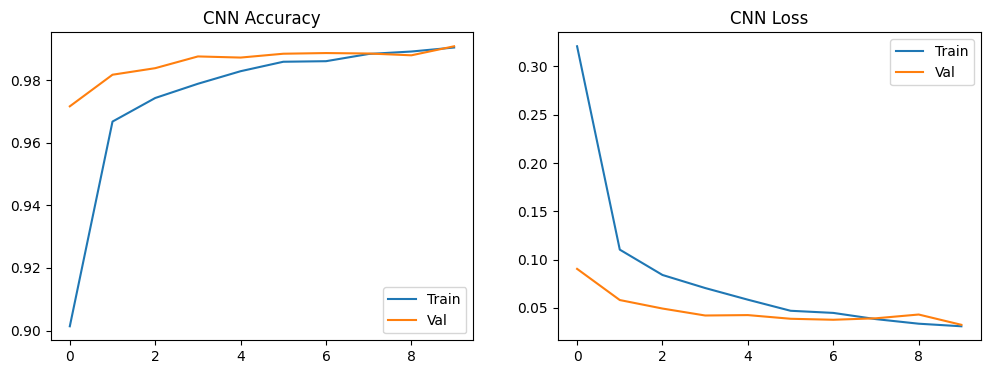

In [70]:

plot_training(history_cnn, "CNN")

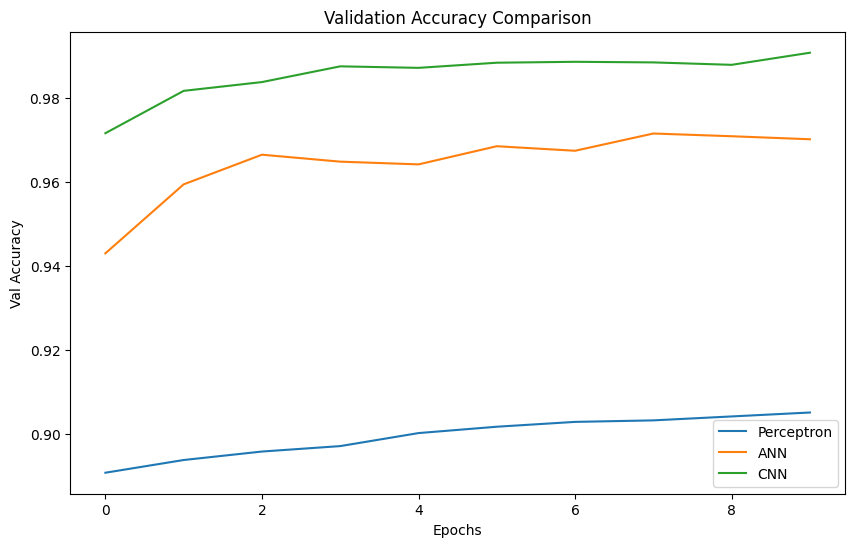

In [72]:

plt.figure(figsize=(10,6))
plt.plot(history_percep.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()
     

In [73]:

def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()
     

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


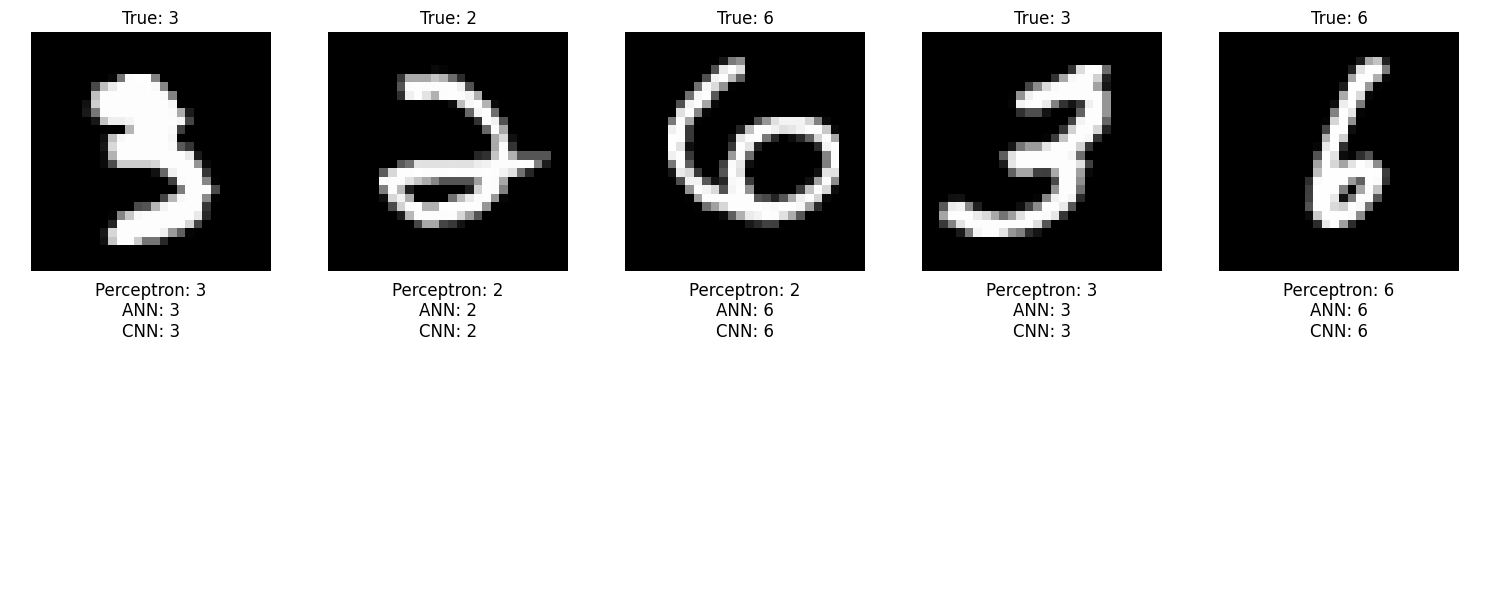

In [78]:
show_side_by_side([Perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], Xtest_img, Xtest_cnn, y_test, 5)
     

434/434 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


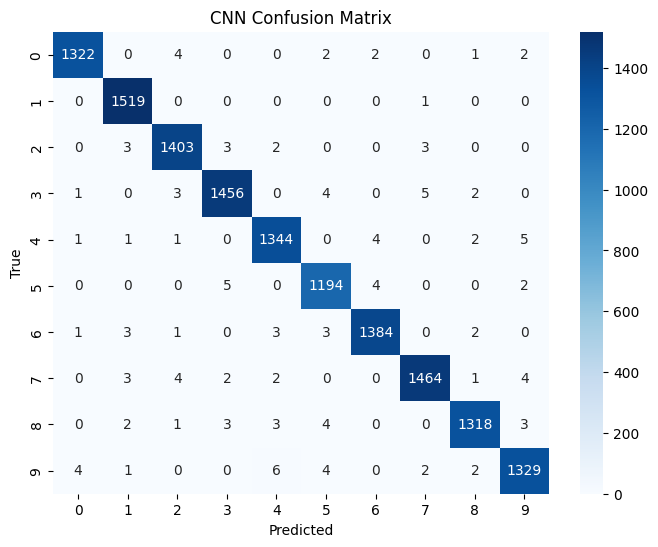

In [80]:

y_pred_cnn = np.argmax(cnn.predict(Xtest_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()